In [2]:
import numpy as np
import pandas as pd

In [3]:
import statsmodels.api as sm

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

In [5]:
frozenfish = {'YEAR': ['1995-96','1996-97','1997-98','1998-99','1999-00','2000-01','2001-02','2002-03','2003-04','2004-05','2005-06','2006-07','2007-08','2008-09','2009-10','2010-11','2011-12','2012-13','2013-14','2014-15','2015-16','2016-17','2017-18','2018-19','2019-20','2020-21',
'2021-22',"2022-23"],'Quantity': [100093,173005,188029,108556,131304,212903,174976,196322,138023,159689,182344,270751,220200,238544,260979,312358,347118,343876,324359,309434,228749,296762,353192,338933,223318,188130,226586,368549],
        'Price': [372.26,636.92,726.73,495.03,537.34,874.68,713.11,841.65,620.73,759.27,998.7,1452.88,1303.41,1722.34,2032.33,2623.89,3284.15,3296.86,4294.81,3778.5,3462.25,4460.9,4674.03,4916.82,3610.01,2941.65,3471.91,5503.1]}
df2=pd.DataFrame(frozenfish)

Dataset has 28 records and 3 columns


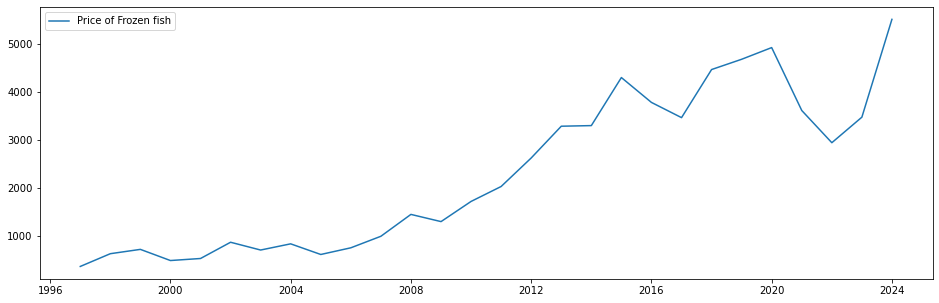

Results of Dickey-Fuller Test:
Test Statistic                 -1.478497
p-value                         0.544120
#Lags Used                      6.000000
Number of Observations Used    21.000000
Critical Value (1%)            -3.788386
Critical Value (5%)            -3.013098
Critical Value (10%)           -2.646397
dtype: float64


In [6]:
# Check the dimensionality of the dataset
df2.shape
print("Dataset has {} records and {} columns".format(df2.shape[0], df2.shape[1]))
# Changing the YEAR data type and setting it as index
df2['YEAR'] = pd.Index(sm.tsa.datetools.dates_from_range('1996', '2023'))
df2.index = df2['YEAR']
# Check the data type
del df2['YEAR']
# View the dataset
df2.head()
# Plotting the Data
# Define the plot size
plt.figure(figsize=(16,5))
# Plot the data
plt.plot(df2.index, df2['Price'], label = "Price of Frozen fish")
plt.legend(loc='best')
plt.show()
# ADF Test
# Function to print out results in customised manner
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    df2test = adfuller(timeseries, autolag='AIC')
    df2output = pd.Series(df2test[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in df2test[4].items():
        df2output['Critical Value (%s)'%key] = value
    print (df2output)
# Call the function and run the test

adf_test(df2['Price'])


In [6]:
df2['Price_diff'] =df2['Price'].diff()

In [7]:
df2= df2.dropna()

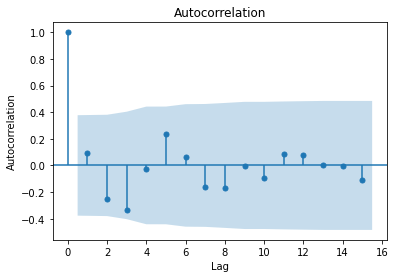

In [8]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
values = df2['Price_diff'].values

#plot  the ACF
plot_acf(values)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()

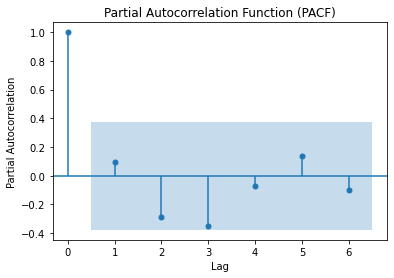

In [9]:
# Plot the PACF
plot_pacf(values,lags=6)
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')
plt.title('Partial Autocorrelation Function (PACF)')
plt.show()

In [10]:

#Augmented Dickey-fuller test
#Dataset1
from statsmodels.tsa.stattools import adfuller
print("Results of Dickey-fuller test:")
df2test = adfuller(df2['Price_diff'],autolag='AIC')
df2output=pd.Series(df2test[0:4],index=['Test Statistic :','p-value :','#lags used :','number of observations used :'])
for key,value in df2test[4].items():
    df2output['critical value (%s)'%key]= value
print(df2output)

Results of Dickey-fuller test:
Test Statistic :                 -3.026063
p-value :                         0.032531
#lags used :                      9.000000
number of observations used :    17.000000
critical value (1%)              -3.889266
critical value (5%)              -3.054358
critical value (10%)             -2.666984
dtype: float64


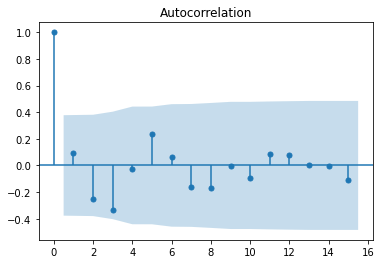

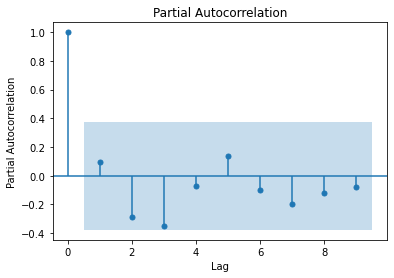

In [11]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
values = df2['Price_diff'].values

#plot  the ACF
plot_acf(values)
plt.show()
# Plot the PACF
plot_pacf(values,lags=9)
plt.xlabel('Lag')
plt.ylabel('Partial Autocorrelation')
plt.show()

In [198]:
frozenfish = {'YEAR': ['1995-96','1996-97','1997-98','1998-99','1999-00','2000-01','2001-02','2002-03','2003-04','2004-05','2005-06','2006-07','2007-08','2008-09','2009-10','2010-11','2011-12','2012-13','2013-14','2014-15','2015-16','2016-17','2017-18','2018-19','2019-20','2020-21',
'2021-22',"2022-23"],'Quantity': [100093,173005,188029,108556,131304,212903,174976,196322,138023,159689,182344,270751,220200,238544,260979,312358,347118,343876,324359,309434,228749,296762,353192,338933,223318,188130,226586,368549],
        'Price': [372.26,636.92,726.73,495.03,537.34,874.68,713.11,841.65,620.73,759.27,998.7,1452.88,1303.41,1722.34,2032.33,2623.89,3284.15,3296.86,4294.81,3778.5,3462.25,4460.9,4674.03,4916.82,3610.01,2941.65,3471.91,5503.1]}
df2=pd.DataFrame(frozenfish)

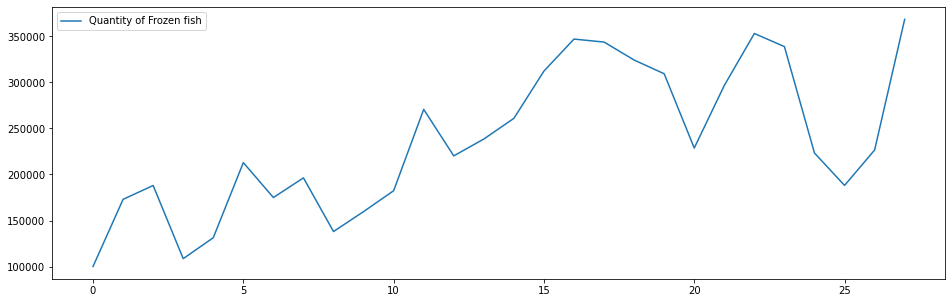

In [199]:
# Plotting the Data
# Define the plot size
plt.figure(figsize=(16,5))
# Plot the data
plt.plot(df2.index, df2['Quantity'], label = "Quantity of Frozen fish")
plt.legend(loc='best')
plt.show()

In [200]:
# ADF Test
# Function to print out results in customised manner
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    df2test = adfuller(timeseries, autolag='AIC')
    df2output = pd.Series(df2test[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in df2test[4].items():
        df2output['Critical Value (%s)'%key] = value
    print (df2output)
# Call the function and run the test

adf_test(df2['Quantity'])


Results of Dickey-Fuller Test:
Test Statistic                 -1.657357
p-value                         0.453207
#Lags Used                      3.000000
Number of Observations Used    24.000000
Critical Value (1%)            -3.737709
Critical Value (5%)            -2.992216
Critical Value (10%)           -2.635747
dtype: float64


In [201]:
df2['Quantity_diff'] =df2['Quantity'].diff()
df2=df2.dropna()

In [202]:
# ADF Test
# Function to print out results in customised manner
from statsmodels.tsa.stattools import adfuller
def adf_test(timeseries):
    print ('Results of Dickey-Fuller Test:')
    df2test = adfuller(timeseries, autolag='AIC')
    df2output = pd.Series(df2test[0:4], index=['Test Statistic','p-value','#Lags Used','Number of Observations Used'])
    for key,value in df2test[4].items():
        df2output['Critical Value (%s)'%key] = value
    print (df2output)
# Call the function and run the test

adf_test(df2['Quantity_diff'])



Results of Dickey-Fuller Test:
Test Statistic                 -5.377405
p-value                         0.000004
#Lags Used                      2.000000
Number of Observations Used    24.000000
Critical Value (1%)            -3.737709
Critical Value (5%)            -2.992216
Critical Value (10%)           -2.635747
dtype: float64


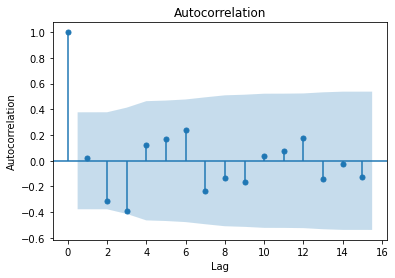

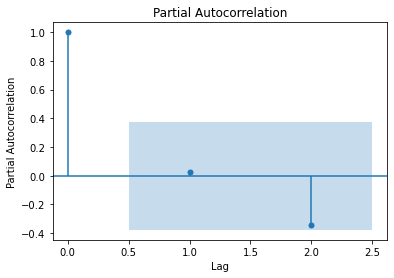

In [203]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
values = df2['Quantity_diff'].values

#plot  the ACF
plot_acf(values)
plt.xlabel('Lag')
plt.ylabel('Autocorrelation')
plt.show()
# Plot the PACF
plot_pacf(values,lags=2)
plt.ylabel('Partial Autocorrelation')
plt.xlabel('Lag')
plt.show()

2 nd obj

In [95]:
import pandas as pd
import numpy as np
import statsmodels.api as sm


# Extract the two variables
variable1 = df2['Quantity']
variable2 = df2['Price']

# Step 1: Perform ADF test to check for unit roots

# Augmented Dickey-Fuller test on variable 1
adf_result1 = sm.tsa.stattools.adfuller(variable1)
adf_stat1 = adf_result1[0]
p_value1 = adf_result1[1]
critical_values1 = adf_result1[4]

# Augmented Dickey-Fuller test on variable 2
adf_result2 = sm.tsa.stattools.adfuller(variable2)
adf_stat2 = adf_result2[0]
p_value2 = adf_result2[1]
critical_values2 = adf_result2[4]

# Check if variables are stationary (reject null hypothesis of unit root)
print(f'p_value1: {p_value1}')
print(f'p_value2: {p_value2}')

if p_value1 > 0.05 and p_value2 > 0.05:
    print("Variables are not stationary. Cannot proceed with Engel-Granger Two-Step procedure.")
else:    
    print("Variables are stationary. Proceeding to Step 2.")


p_value1: 0.7448824821136658
p_value2: 0.4798434650371286
Variables are not stationary. Cannot proceed with Engel-Granger Two-Step procedure.


p_value1: 4.583923279198301e-06
p_value2: 0.07967153674628591
Variables are stationary. Proceeding to Step 2.


In [127]:
# Estimate the cointegrating relationship using OLS

# Add a constant column to the independent variable
variable1_with_constant = sm.add_constant(df2['Quantity'])

# Fit the OLS model
model = sm.OLS(df2['Price'], variable1_with_constant)
result = model.fit()

# Get the estimated coefficients
intercept = result.params[0]
slope = result.params[1]

# Print the results
print("Cointegrating Relationship:")
print("Price = {} + {} * Quantity".format(intercept, slope))
print("\nOLS Summary:")
print(result.summary())


Cointegrating Relationship:
Price = -1798.9014764479912 + 0.017345334596207778 * Quantity

OLS Summary:
                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.713
Model:                            OLS   Adj. R-squared:                  0.702
Method:                 Least Squares   F-statistic:                     64.48
Date:                Mon, 17 Jul 2023   Prob (F-statistic):           1.65e-08
Time:                        01:43:04   Log-Likelihood:                -228.81
No. Observations:                  28   AIC:                             461.6
Df Residuals:                      26   BIC:                             464.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
---------------------------

In [98]:
# VAR model

In [209]:
# 3rd obj VAR model
import pandas as pd
import numpy as np
from statsmodels.tsa.api import VAR

# Extract the variables of interest
variables = df2[['Quantity', 'Price']]

# Create a VAR model with a specified lag order (p)
model = VAR(variables)
results = model.fit(maxlags=2) 
parameters = model_fit.params
print("Parameter Estimates:")
print(parameters)
print("\n")

# Print the estimated coefficients
print("Estimated Coefficients:")
print(results.coefs)

# Forecast future values
n_periods = 10  # Number of periods to forecast
forecast = results.forecast(variables.values[-2:], steps=n_periods)  # Specify the appropriate lag order

# Print the forecasted values
print("Forecasted Values:")
print(forecast)



Parameter Estimates:
                  Quantity_diff  Price_diff
const               3679.134287  182.597573
L1.Quantity_diff      -0.235290    0.001283
L1.Price_diff         35.678693    0.050333


Estimated Coefficients:
[[[ 1.37446226e-01  8.32018671e+01]
  [-2.08382660e-03  1.30581481e+00]]

 [[-1.77205597e-02 -5.62909485e+01]
  [-2.07806300e-03 -1.68419614e-01]]]
Forecasted Values:
[[457379.75227486   6194.30654502]
 [410245.60360355   6274.68611262]
 [369972.12017752   6176.85769647]
 [352607.77637396   6217.445092  ]
 [359818.58293441   6406.7960555 ]
 [374587.03768977   6668.27576477]
 [387585.98122965   6932.07001703]
 [396340.16516098   7174.72082375]
 [402652.81766613   7401.89489043]
 [408607.60134046   7626.32877764]]


In [1]:
frozenfish = {'YEAR': ['1995-96','1996-97','1997-98','1998-99','1999-00','2000-01','2001-02','2002-03','2003-04','2004-05','2005-06','2006-07','2007-08','2008-09','2009-10','2010-11','2011-12','2012-13','2013-14','2014-15','2015-16','2016-17','2017-18','2018-19','2019-20','2020-21',
'2021-22',"2022-23"],'Quantity': [100093,173005,188029,108556,131304,212903,174976,196322,138023,159689,182344,270751,220200,238544,260979,312358,347118,343876,324359,309434,228749,296762,353192,338933,223318,188130,226586,368549],
        'Price': [372.26,636.92,726.73,495.03,537.34,874.68,713.11,841.65,620.73,759.27,998.7,1452.88,1303.41,1722.34,2032.33,2623.89,3284.15,3296.86,4294.81,3778.5,3462.25,4460.9,4674.03,4916.82,3610.01,2941.65,3471.91,5503.1]}
df2=pd.DataFrame(frozenfish)

NameError: name 'pd' is not defined

In [10]:
# Assuming you have a DataFrame 'data' containing the price and quantity variables.
# We'll use the ADF test to check for stationarity.
from statsmodels.tsa.stattools import adfuller
data=df2[['Price','Quantity']]
def are_series_stationary(data, threshold=0.05):
    result = adfuller(data)
    p_value = result[1]
    return p_value <= threshold

# Test for stationarity of price and quantity
is_price_stationary = are_series_stationary(df2['Price'])
is_quantity_stationary = are_series_stationary(df2
                                               ['Quantity'])

# If both series are non-stationary, proceed with cointegration test
if not is_price_stationary and not is_quantity_stationary:
    result = coint_johansen(data, det_order=0, k_ar_diff=1)

    # Get the trace statistics and critical values for different significance levels (e.g., 90%, 95%, 99%)
    trace_statistic = result.lr1
    trace_critical_values = result.cvt[:, 1]  # Use 1% critical value (you can choose other values as well)

    # Find the number of cointegrated vectors (relationships)
    num_cointegrated_vectors = sum(trace_statistic > trace_critical_values)

    if num_cointegrated_vectors > 0:
        print("The variables price and quantity are cointegrated.")
    else:
        print("The variables price and quantity are not cointegrated.")
else:
    print("Both variables should be non-stationary for cointegration testing.")


The variables price and quantity are cointegrated.


In [11]:
num_cointegrated_vectors

1

In [12]:
import pandas as pd
import numpy as np
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM

# Extract the variables
variables = df2[[ 'Quantity','Price']]

# Perform Johansen cointegration test
coint_result = coint_johansen(variables, det_order=-1, k_ar_diff=1)

# Extract the cointegrating vectors
coint_vectors = coint_result.evec

# Specify the number of cointegrating vectors to use for prediction
num_coint_vectors = 1

# Create the VECM model using the cointegrating vectors
model = VECM(variables, k_ar_diff=1, coint_rank=num_coint_vectors, deterministic='nc')
model_fit = model.fit(method='ml')

vecm_res = model.fit()
vecm_res.gamma.round(4)
vecm_res.summary()
print(model)
# Generate predictions for the next 'n' steps
n = 10
forecast = model_fit.predict(steps=10)

# Print the forecasted values
print("Forecasted Values:")
print(forecast)
model_fit.predict(10, 0.05)

Forecasted Values:
[[412749.52820423   5943.3476698 ]
 [415394.53304396   6219.80242841]
 [420930.15131201   6452.69011596]
 [424070.71656987   6685.35712824]
 [427756.25296408   6915.60641197]
 [431230.1149453    7145.7852915 ]
 [434758.4631583    7375.38200854]
 [438260.23758634   7604.59369843]
 [441761.75819644   7833.36341583]
 [445254.73962707   8061.71100173]]


C:\ProgramData\Anaconda3\lib\site-packages\statsmodels\tsa\base\tsa_model.py:524: ValueWarning: No frequency information was provided, so inferred frequency A-DEC will be used.
  warnings.warn('No frequency information was'


(array([[412749.52820423,   5943.3476698 ],
        [415394.53304396,   6219.80242841],
        [420930.15131201,   6452.69011596],
        [424070.71656987,   6685.35712824],
        [427756.25296408,   6915.60641197],
        [431230.1149453 ,   7145.7852915 ],
        [434758.4631583 ,   7375.38200854],
        [438260.23758634,   7604.59369843],
        [441761.75819644,   7833.36341583],
        [445254.73962707,   8061.71100173]]),
 array([[302783.40708381,   4735.71805979],
        [247774.28959447,   4359.74226296],
        [209115.35816098,   4054.20838395],
        [174943.78077331,   3808.46621297],
        [145655.56959929,   3592.68702183],
        [119105.11987177,   3396.4752844 ],
        [ 94781.79403086,   3211.79135693],
        [ 72103.56635411,   3034.26711339],
        [ 50758.55418959,   2860.80320907],
        [ 30495.8600945 ,   2689.32039706]]),
 array([[522715.64932465,   7150.97727981],
        [583014.77649345,   8079.86259387],
        [632744.94446304,   

In [13]:
coint_vectors

array([[ 5.26087264e-06, -1.03358802e-05],
       [-9.34857890e-05,  1.05148856e-03]])

In [14]:
vecm_res = model.fit()

In [15]:
vecm_res

In [16]:
vecm_res.gamma.round(4)

array([[-2.24600e-01,  3.95636e+01],
       [ 7.00000e-04,  7.47000e-02]])

In [17]:
vecm_res.summary()

,coef,std err,z,P>|z|,[0.025,0.975]
L1.Quantity,-0.2246,0.306,-0.735,0.463,-0.824,0.375
L1.Price,39.5636,33.295,1.188,0.235,-25.693,104.820
,coef,std err,z,P>|z|,[0.025,0.975]
L1.Quantity,0.0007,0.003,0.213,0.831,-0.006,0.007
L1.Price,0.0747,0.366,0.204,0.838,-0.642,0.791
,coef,std err,z,P>|z|,[0.025,0.975]
ec1,-0.0158,0.058,-0.272,0.785,-0.129,0.098
,coef,std err,z,P>|z|,[0.025,0.975]
ec1,0.0007,0.001,1.085,0.278,-0.001,0.002
,coef,std err,z,P>|z|,[0.025,0.975]


lower bounds of confidence intervals:
[[302783.407   4735.718]
 [247774.29    4359.742]
 [209115.358   4054.208]
 [174943.781   3808.466]
 [145655.57    3592.687]]

point forecasts:
[[412749.528   5943.348]
 [415394.533   6219.802]
 [420930.151   6452.69 ]
 [424070.717   6685.357]
 [427756.253   6915.606]]

upper bounds of confidence intervals:
[[522715.649   7150.977]
 [583014.776   8079.863]
 [632744.944   8851.172]
 [673197.652   9562.248]
 [709856.936  10238.526]]


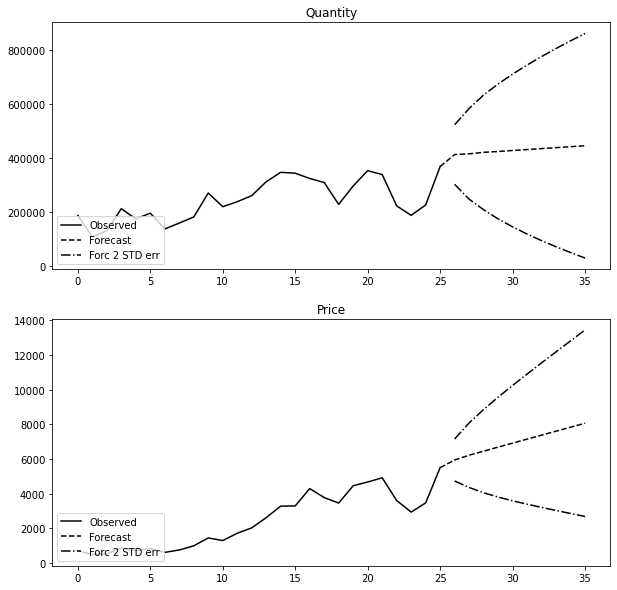

In [18]:
vecm_res.predict(steps=5)
forecast, lower, upper = vecm_res.predict(5, 0.05)
print("lower bounds of confidence intervals:")
print(lower.round(3))
print("\npoint forecasts:")
print(forecast.round(3))
print("\nupper bounds of confidence intervals:")
print(upper.round(3))
vecm_res.plot_forecast(steps=10)


lower bounds of confidence intervals:
[[302783.407   4735.718]
 [247774.29    4359.742]
 [209115.358   4054.208]
 [174943.781   3808.466]
 [145655.57    3592.687]]

point forecasts:
[[412749.528   5943.348]
 [415394.533   6219.802]
 [420930.151   6452.69 ]
 [424070.717   6685.357]
 [427756.253   6915.606]]

upper bounds of confidence intervals:
[[522715.649   7150.977]
 [583014.776   8079.863]
 [632744.944   8851.172]
 [673197.652   9562.248]
 [709856.936  10238.526]]


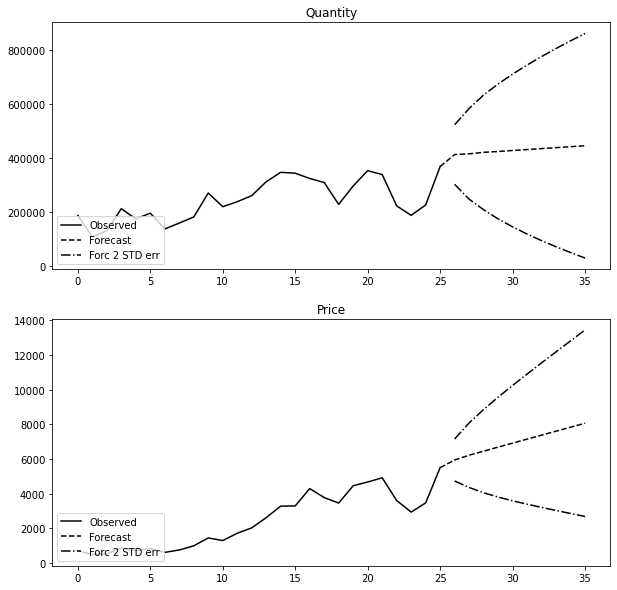

In [22]:
vecm_res.predict(steps=5)
forecast, lower, upper = vecm_res.predict(5, 0.05)
print("lower bounds of confidence intervals:")
print(lower.round(3))
print("\npoint forecasts:")
print(forecast.round(3))
print("\nupper bounds of confidence intervals:")
print(upper.round(3))
vecm_res.plot_forecast(steps=10)


ValueError: x and y must have same first dimension, but have shapes (28,) and (5, 2)

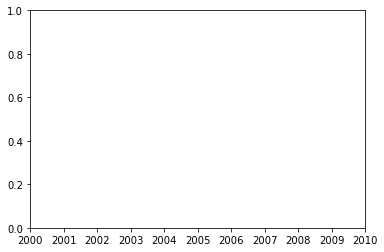

In [21]:
plt.plot(df2.index, forecast, label = "Price of Frozen fish")
plt.legend(loc='best')
plt.show()